# Notebook 2 (customer_data): GMM trên RFM

## Đầu vào
- `data_customer/rfm_customers.csv` từ `01_DataProcessing_customer_data.ipynb`.
- Đặc trưng: `R_z`, `F_z`, `M_z`.

## Output
- `data_customer/gmm_model_selection.csv`, `data_customer/rfm_with_gmm.csv`
- `models_customer/gmm_rfm.joblib`

Cùng tham số GMM / K_CAP như `02_GMM.ipynb`.


In [1]:
from __future__ import annotations

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

def _project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "requirements.txt").is_file():
            return p
        if p.parent == p:
            break
        p = p.parent
    return Path.cwd().resolve()


ROOT = _project_root()
DATA_PATH = ROOT / "data_customer" / "rfm_customers.csv"
MODEL_DIR = ROOT / "models_customer"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR = ROOT / "data_customer"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = ["R_z", "F_z", "M_z"]
RANDOM_STATE = 42

N_INIT = 10
MAX_ITER = 300
REG_COVAR = 1e-3
COVARIANCE_TYPE = "full"

K_MIN, K_MAX = 2, 12
K_CAP = 8


In [2]:
rfm = pd.read_csv(DATA_PATH)

X = rfm[FEATURE_COLS].to_numpy(dtype=float)
print("Shape X:", X.shape)
print(rfm[FEATURE_COLS].describe())


Shape X: (10000, 3)
                R_z           F_z           M_z
count  1.000000e+04  1.000000e+04  1.000000e+04
mean  -4.334311e-17  9.023893e-17  1.030287e-15
std    1.000050e+00  1.000050e+00  1.000050e+00
min   -1.704196e+00 -6.431782e+00 -6.046357e+00
25%   -8.450964e-01 -5.338059e-01 -5.715376e-01
50%   -2.036066e-02  1.581457e-01  1.416209e-01
75%    8.731030e-01  7.173981e-01  7.262614e-01
max    1.697839e+00  2.028845e+00  2.125474e+00


In [3]:
rows = []
for k in range(K_MIN, K_MAX + 1):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=COVARIANCE_TYPE,
        random_state=RANDOM_STATE,
        n_init=N_INIT,
        max_iter=MAX_ITER,
        reg_covar=REG_COVAR,
    )
    gmm.fit(X)
    rows.append(
        {
            "n_components": k,
            "aic": gmm.aic(X),
            "bic": gmm.bic(X),
            "log_likelihood": gmm.score(X) * len(X),
        }
    )

crit = pd.DataFrame(rows)
crit_path = OUT_DIR / "gmm_model_selection.csv"
crit.to_csv(crit_path, index=False)
print("Đã lưu:", crit_path.resolve())
crit


Đã lưu: /Users/kotori/GMS_AFKMC2/data_customer/gmm_model_selection.csv


,n_components,aic,bic,log_likelihood
0,2,83244.986249,83381.982716,-41603.493125
1,3,81972.330793,82181.430664,-40957.165397
2,4,81816.828801,82098.032075,-40869.414400
3,5,81591.005390,81944.312069,-40746.502695
4,6,81440.090501,81865.500583,-40661.045250
5,7,81352.241903,81849.755389,-40607.120952
6,8,80453.937402,81023.554292,-40147.968701
7,9,80282.372061,80924.092354,-40052.186030
8,10,80286.939363,81000.763060,-40044.469682
9,11,80076.371956,80862.299056,-39929.185978


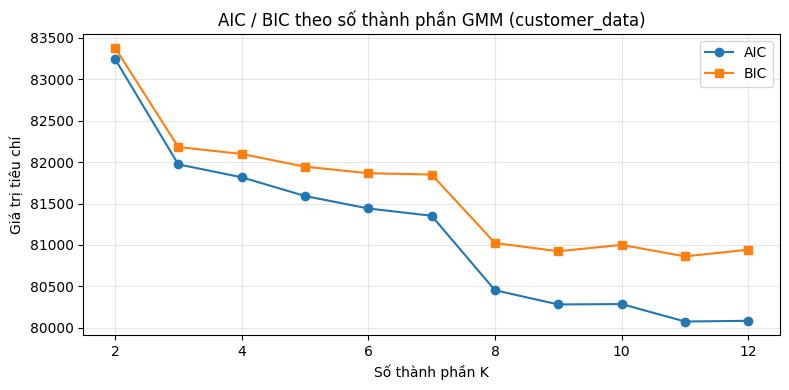

K theo BIC (sau giới hạn K_CAP): 8 | K_CAP = 8
Số thành phần GMM dùng để fit cuối: 8


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(crit["n_components"], crit["aic"], marker="o", label="AIC")
ax.plot(crit["n_components"], crit["bic"], marker="s", label="BIC")
ax.set_xlabel("Số thành phần K")
ax.set_ylabel("Giá trị tiêu chí")
ax.legend()
ax.grid(True, alpha=0.3)
plt.title("AIC / BIC theo số thành phần GMM (customer_data)")
plt.tight_layout()
plt.show()

if K_CAP is None:
    best_k = int(crit.loc[crit["bic"].idxmin(), "n_components"])
else:
    sub = crit[crit["n_components"] <= K_CAP]
    best_k = int(sub.loc[sub["bic"].idxmin(), "n_components"])
print("K theo BIC (sau giới hạn K_CAP):", best_k, "| K_CAP =", K_CAP)

USE_FIXED_K = False
FIXED_K = 4

N_COMPONENTS = FIXED_K if USE_FIXED_K else best_k
print("Số thành phần GMM dùng để fit cuối:", N_COMPONENTS)


In [5]:
gmm_final = GaussianMixture(
    n_components=N_COMPONENTS,
    covariance_type=COVARIANCE_TYPE,
    random_state=RANDOM_STATE,
    n_init=N_INIT,
    max_iter=MAX_ITER,
    reg_covar=REG_COVAR,
)
gmm_final.fit(X)

proba = gmm_final.predict_proba(X)
labels = gmm_final.predict(X)
rfm_out = rfm.copy()
rfm_out["gmm_component"] = labels
rfm_out["gmm_max_proba"] = proba.max(axis=1)

for j in range(N_COMPONENTS):
    rfm_out[f"gmm_p_{j}"] = proba[:, j]

model_path = MODEL_DIR / "gmm_rfm.joblib"
joblib.dump(
    {
        "gmm": gmm_final,
        "feature_cols": FEATURE_COLS,
        "n_components": N_COMPONENTS,
        "covariance_type": COVARIANCE_TYPE,
        "bic_used_for_selection": not USE_FIXED_K,
        "best_k_by_bic": best_k,
    },
    model_path,
)
print("Đã lưu mô hình:", model_path.resolve())

csv_path = OUT_DIR / "rfm_with_gmm.csv"
rfm_out.to_csv(csv_path, index=False)
print("Đã lưu bảng:", csv_path.resolve())
rfm_out.head()


Đã lưu mô hình: /Users/kotori/GMS_AFKMC2/models_customer/gmm_rfm.joblib
Đã lưu bảng: /Users/kotori/GMS_AFKMC2/data_customer/rfm_with_gmm.csv


,customer_id,R,F,M,F_log1p,M_log1p,R_z,F_z,M_z,gmm_component,gmm_max_proba,gmm_p_0,gmm_p_1,gmm_p_2,gmm_p_3,gmm_p_4,gmm_p_5,gmm_p_6,gmm_p_7
0,1,68,12,1265.0,2.564949,7.143618,0.632555,-0.952687,-0.289916,2,0.652894,0.025496,0.232330,0.652894,0.010141,0.011021,9.226768e-04,0.067196,1.552358e-17
1,2,99,12,1647.0,2.564949,7.407318,1.697839,-0.952687,0.557281,2,0.547484,0.002524,0.016561,0.547484,0.000005,0.000019,4.197285e-01,0.013678,6.294097e-39
2,3,63,19,1806.0,2.995732,7.499423,0.460735,0.308290,0.853192,0,0.625841,0.625841,0.084554,0.249028,0.020710,0.018294,3.566089e-04,0.001217,3.589503e-14
3,4,65,22,1207.0,3.135494,7.096721,0.529463,0.717398,-0.440581,0,0.477479,0.477479,0.414472,0.059295,0.008787,0.032879,1.116192e-03,0.005973,3.916680e-15
4,5,49,17,934.0,2.890372,6.840547,-0.020361,-0.000119,-1.263602,4,0.453588,0.104286,0.329239,0.011955,0.026471,0.453588,1.051175e-09,0.074461,2.121991e-08


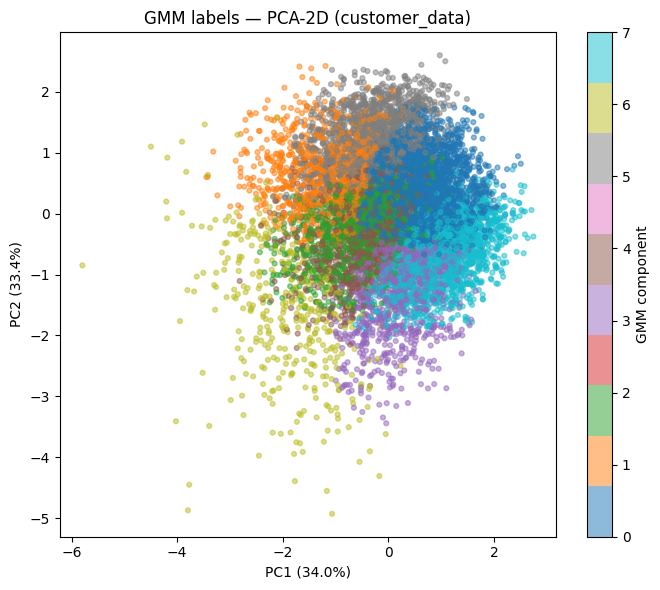

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X2[:, 0], X2[:, 1], c=labels, cmap="tab10", alpha=0.5, s=12)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.colorbar(scatter, ax=ax, label="GMM component")
plt.title("GMM labels — PCA-2D (customer_data)")
plt.tight_layout()
plt.show()
